# Explainable AI for Candidate Selection

This predicts whether a candidate will be selected based on experience, test score, and interview score. It also explains the prediction using SHAP and LIME so the result is easy to understand.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap
from lime.lime_tabular import LimeTabularExplainer

In [2]:
# This makes sure we get the same output every time we run the notebook.
np.random.seed(42)

In [4]:
# This is synthetic data created for learning purpose.

data = pd.DataFrame({
    "experience": np.random.randint(0, 10, 200),
    "test_score": np.random.randint(40, 100, 200),
    "interview_score": np.random.randint(40, 100, 200)
})

data.head()

,experience,test_score,interview_score
0,4,53,64
1,1,48,56
2,7,85,52
3,3,40,59
4,8,90,64


In [5]:
# selected = 1 means candidate is selected
# selected = 0 means candidate is not selected

data["selected"] = (
    (data["test_score"] > 70) &
    (data["interview_score"] > 65)
).astype(int)

data.head()

,experience,test_score,interview_score,selected
0,4,53,64,0
1,1,48,56,0
2,7,85,52,0
3,3,40,59,0
4,8,90,64,0


In [8]:
print("Dataset shape:", data.shape)

print("\nFirst 5 rows:")
display(data.head())

print("\nMissing values:")
print(data.isnull().sum())

print("\nClass distribution:")
print(data["selected"].value_counts())

Dataset shape: (200, 4)

First 5 rows:


,experience,test_score,interview_score,selected
0,4,53,64,0
1,1,48,56,0
2,7,85,52,0
3,3,40,59,0
4,8,90,64,0



Missing values:
experience         0
test_score         0
interview_score    0
selected           0
dtype: int64

Class distribution:
selected
0    144
1     56
Name: count, dtype: int64


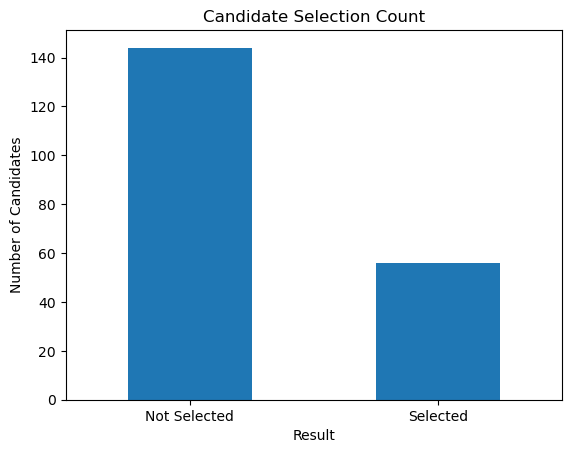

In [9]:
# Show selected vs not selected count using a chart
selection_count = data["selected"].value_counts().rename(index={0: "Not Selected", 1: "Selected"})

selection_count.plot(kind="bar")
plt.title("Candidate Selection Count")
plt.xlabel("Result")
plt.ylabel("Number of Candidates")
plt.xticks(rotation=0)
plt.show()

In [11]:
# Separate input features and output label
X = data[["experience", "test_score", "interview_score"]]
y = data["selected"]

In [13]:
# Split data into training and testing parts
# stratify=y keeps selected/not-selected ratio balanced in both train and test data.
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.3,random_state=42,stratify=y
)

In [14]:
# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [16]:
# Test Logistic Regression model
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_accuracy, 3))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=["Not Selected", "Selected"]))

Logistic Regression Accuracy: 0.95

Classification Report:
              precision    recall  f1-score   support

Not Selected       0.98      0.95      0.96        43
    Selected       0.89      0.94      0.91        17

    accuracy                           0.95        60
   macro avg       0.93      0.95      0.94        60
weighted avg       0.95      0.95      0.95        60



In [17]:
# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,max_depth=5,random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [19]:
# Test Random Forest model
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 3))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=["Not Selected", "Selected"]))

Random Forest Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

Not Selected       1.00      1.00      1.00        43
    Selected       1.00      1.00      1.00        17

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [20]:
# Compare both models in a simple table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy]
})

results["Accuracy"] = results["Accuracy"].round(3)
display(results)

,Model,Accuracy
0,Logistic Regression,0.95
1,Random Forest,1.00


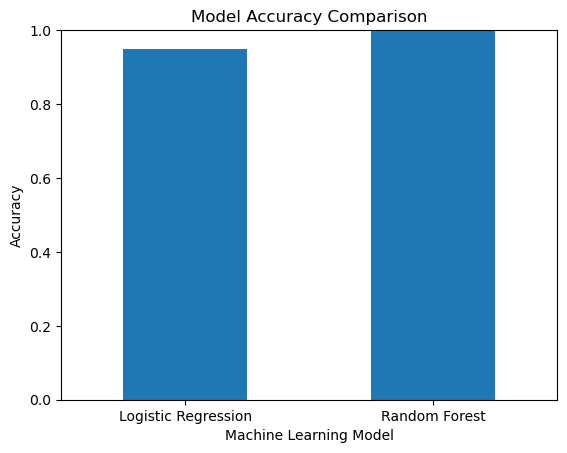

In [21]:
# Show model comparison using a chart
results.plot(kind="bar", x="Model", y="Accuracy", legend=False)
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

In [22]:
# Confusion matrix for Random Forest
# This shows correct and wrong predictions clearly.
cm = confusion_matrix(y_test, rf_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Selected", "Actual Selected"],
    columns=["Predicted Not Selected", "Predicted Selected"]
)

display(cm_df)

,Predicted Not Selected,Predicted Selected
Actual Not Selected,43,0
Actual Selected,0,17


## Explainability using SHAP

SHAP helps us understand which input features affect the model prediction the most. This makes the machine learning model easier to explain.

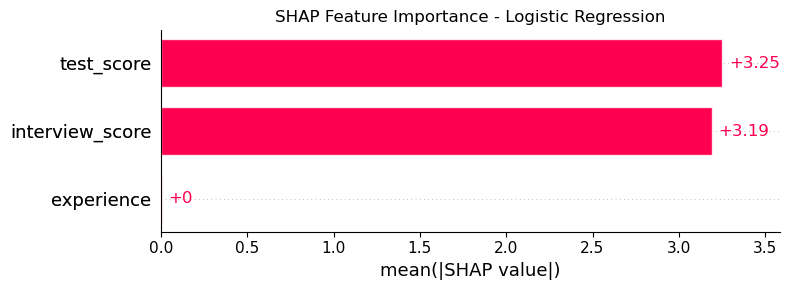

Saved image: shap_lr_bar.png


In [23]:
# SHAP explanation for Logistic Regression
lr_explainer = shap.Explainer(lr_model, X_train)
lr_shap_values = lr_explainer(X_test)

shap.plots.bar(lr_shap_values, show=False)
plt.title("SHAP Feature Importance - Logistic Regression")
plt.tight_layout()
plt.savefig("shap_lr_bar.png", dpi=150)
plt.show()

print("Saved image: shap_lr_bar.png")

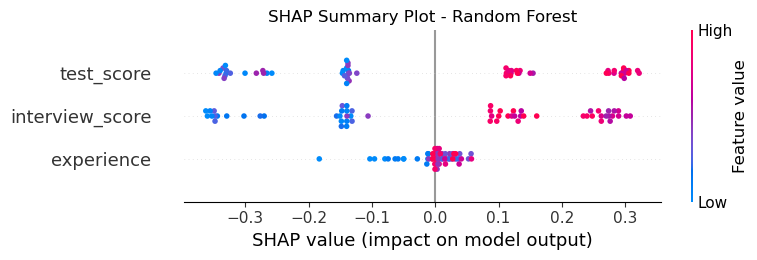

Saved image: shap_rf_summary.png


In [24]:
# SHAP explanation for Random Forest
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_test)

# For binary classification, class 1 means Selected.
shap.summary_plot(rf_shap_values[:, :, 1], X_test, show=False)
plt.title("SHAP Summary Plot - Random Forest")
plt.tight_layout()
plt.savefig("shap_rf_summary.png", dpi=150)
plt.show()

print("Saved image: shap_rf_summary.png")

## Explainability using LIME

LIME explains one single prediction. It tells us why the model selected or rejected one particular candidate.

In [26]:
# Create LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns.tolist(),
    class_names=["Not Selected", "Selected"],
    mode="classification"
)

In [28]:
# Explain one candidate from test data using LIME
candidate_index = 0
instance = X_test.iloc[candidate_index].values

exp = lime_explainer.explain_instance(instance, rf_model.predict_proba)

print("Candidate values:")
display(X_test.iloc[[candidate_index]])

print("\nLIME explanation:")
for feature, weight in exp.as_list():
    print(f"{feature:35s} {weight:+.4f}")

Candidate values:


,experience,test_score,interview_score
45,2,78,69



LIME explanation:
67.50 < interview_score <= 79.25    +0.2983
69.50 < test_score <= 86.00         +0.2938
experience <= 2.00                  -0.0181


In [29]:
# Save LIME explanation as HTML file
exp.save_to_file("lime_explanation.html")
print("Saved file: lime_explanation.html")

Saved file: lime_explanation.html


In [32]:
# Create a user-friendly prediction function

def predict_candidate(experience, test_score, interview_score):
    input_data = pd.DataFrame([{
        "experience": experience,
        "test_score": test_score,
        "interview_score": interview_score
    }])

    prediction = rf_model.predict(input_data)[0]
    probability = rf_model.predict_proba(input_data)[0][1]

    result = "Selected" if prediction == 1 else "Not Selected"

    print("Candidate Details")
    print("Experience:", experience, "years")
    print("Test Score:", test_score)
    print("Interview Score:", interview_score)
    print("\nFinal Result:", result)
    print("Selection Chance:", round(probability * 100, 2), "%")

    return result, probability

In [33]:
# Test the prediction function
predict_candidate(experience=5, test_score=75, interview_score=70)

Candidate Details
Experience: 5 years
Test Score: 75
Interview Score: 70

Final Result: Selected
Selection Chance: 88.82 %


('Selected', np.float64(0.8882406441179583))

## Final Conclusion

In this project, I built a machine learning model to predict whether a candidate will be selected or not based on experience, test score, and interview score. I compared Logistic Regression and Random Forest. Random Forest was used for final prediction because it performed well and can capture non-linear patterns. I also used SHAP and LIME to explain the model results, so even non-technical users can understand why a candidate was selected or not selected.